In [1]:
!pip install -q kagglehub mlxtend

In [2]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.data import loadlocal_mnist
from sklearn.model_selection import train_test_split


Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset
Files in dataset:
t10k-labels-idx1-ubyte
train-images.idx3-ubyte
t10k-images-idx3-ubyte
t10k-labels.idx1-ubyte
t10k-images.idx3-ubyte
train-labels.idx1-ubyte
train-labels-idx1-ubyte
train-images-idx3-ubyte
Images Shape: (60000, 784)
Labels Shape: (60000,)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0
Training Data: (48000, 784)
Testing Data : (12000, 784)


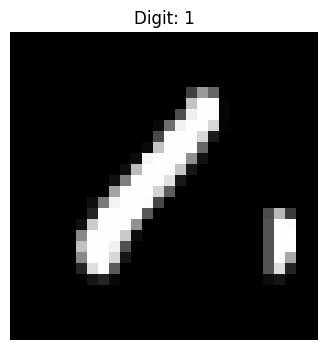

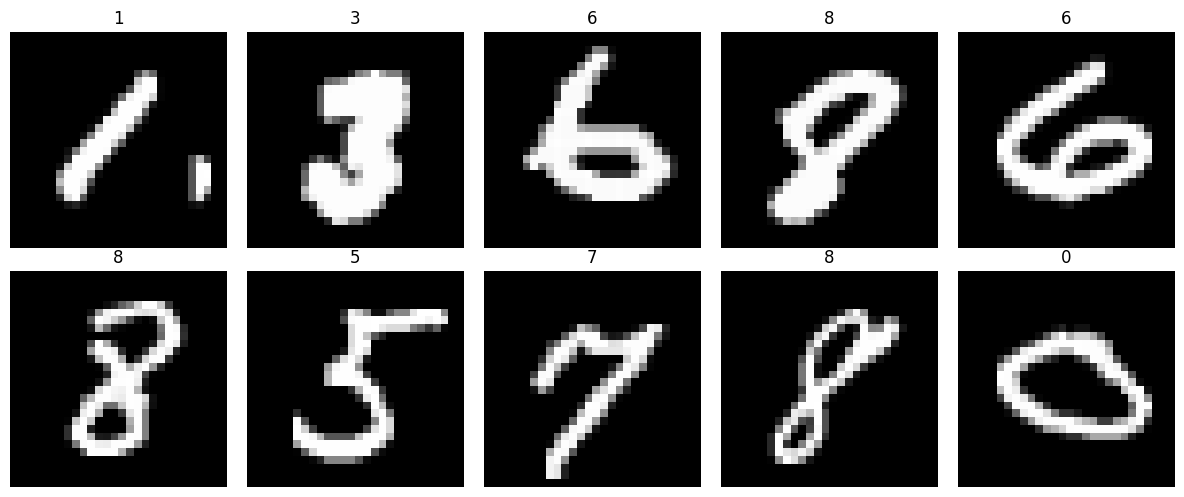

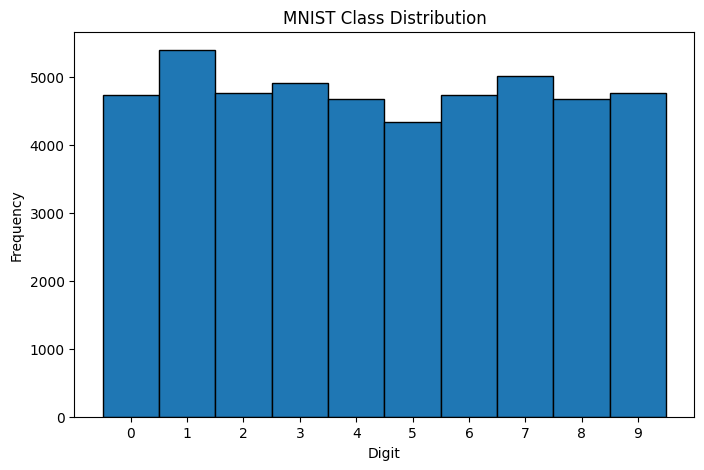

Training Images : (48000, 784)
Testing Images  : (12000, 784)
Training Labels : (48000,)
Testing Labels  : (12000,)
Pixel Value Range : 0.0 to 1.0


In [3]:
# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

print("Files in dataset:")

for file in os.listdir(path):
    print(file)

X, y = loadlocal_mnist(
    images_path=os.path.join(path, "train-images.idx3-ubyte"),
    labels_path=os.path.join(path, "train-labels.idx1-ubyte")
)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

X = X.astype("float32") / 255.0

print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

plt.figure(figsize=(4,4))
plt.imshow(X_train[0].reshape(28,28), cmap="gray")
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.hist(
    y_train,
    bins=np.arange(11)-0.5,
    edgecolor="black"
)

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("MNIST Class Distribution")

plt.show()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

print("Pixel Value Range :", X_train.min(), "to", X_train.max())